In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


df = pd.read_csv('../data/insurance.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

=== Basic Statistics ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


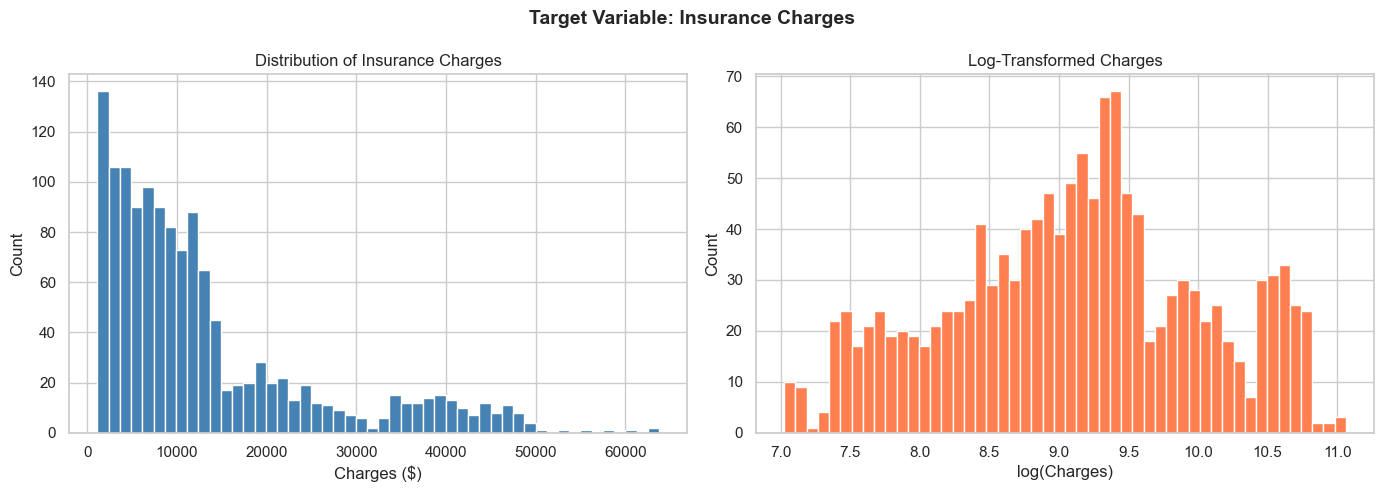

Skewness (original): 1.516
Skewness (log):      -0.090


In [3]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Count')


axes[1].hist(np.log1p(df['charges']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Insurance Charges', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness (original): {df['charges'].skew():.3f}")
print(f"Skewness (log):      {np.log1p(df['charges']).skew():.3f}")

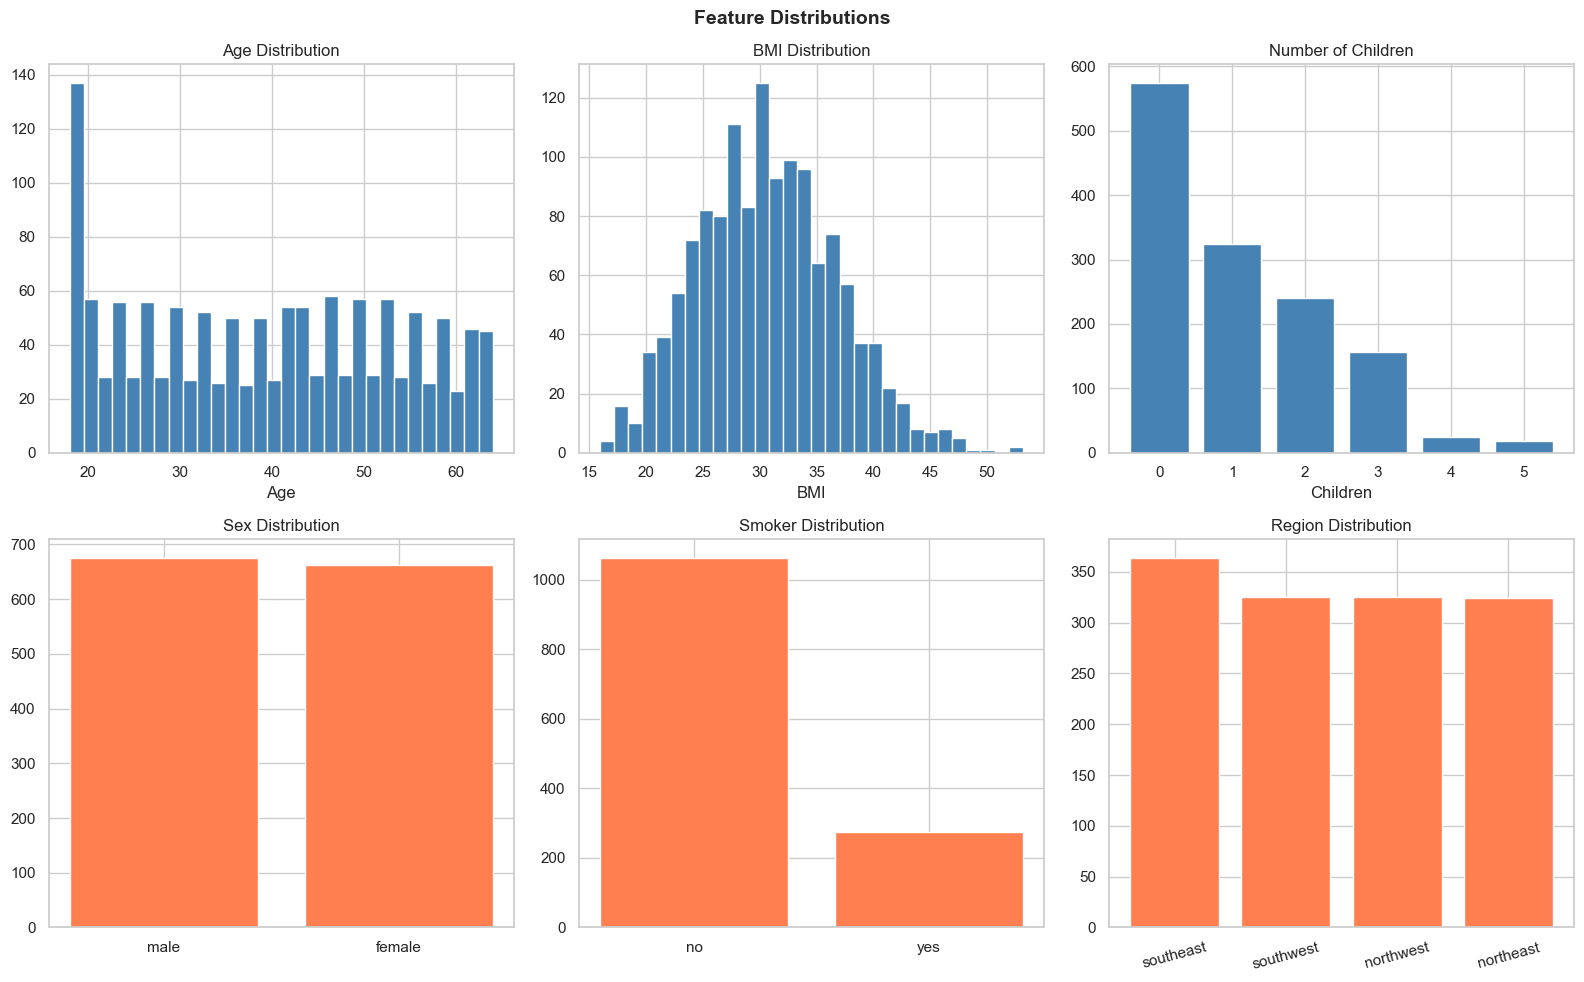

In [4]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age
axes[0,0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# BMI
axes[0,1].hist(df['bmi'], bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('BMI Distribution')
axes[0,1].set_xlabel('BMI')

# Children
axes[0,2].bar(df['children'].value_counts().index, 
              df['children'].value_counts().values, color='steelblue')
axes[0,2].set_title('Number of Children')
axes[0,2].set_xlabel('Children')

# Sex
axes[1,0].bar(df['sex'].value_counts().index,
              df['sex'].value_counts().values, color='coral')
axes[1,0].set_title('Sex Distribution')

# Smoker
axes[1,1].bar(df['smoker'].value_counts().index,
              df['smoker'].value_counts().values, color='coral')
axes[1,1].set_title('Smoker Distribution')

# Region
axes[1,2].bar(df['region'].value_counts().index,
              df['region'].value_counts().values, color='coral')
axes[1,2].set_title('Region Distribution')
axes[1,2].tick_params(axis='x', rotation=15)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\jehay\AppData\Local\Temp\ipykernel_39116\3791377580.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([df[df['children']==i]['charges'] for i in range(6)],
C:\Users\jehay\AppData\Local\Temp\ipykernel_39116\3791377580.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([df[df['smoker']=='no']['charges'],
C:\Users\jehay\AppData\Local\Temp\ipykernel_39116\3791377580.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([df[df['sex']=='male']['charges'],
C:\Users\jehay\AppData\Local\Temp\ipykernel_39116\3791377580.py:34: MatplotlibDeprecationWarning: The 'l

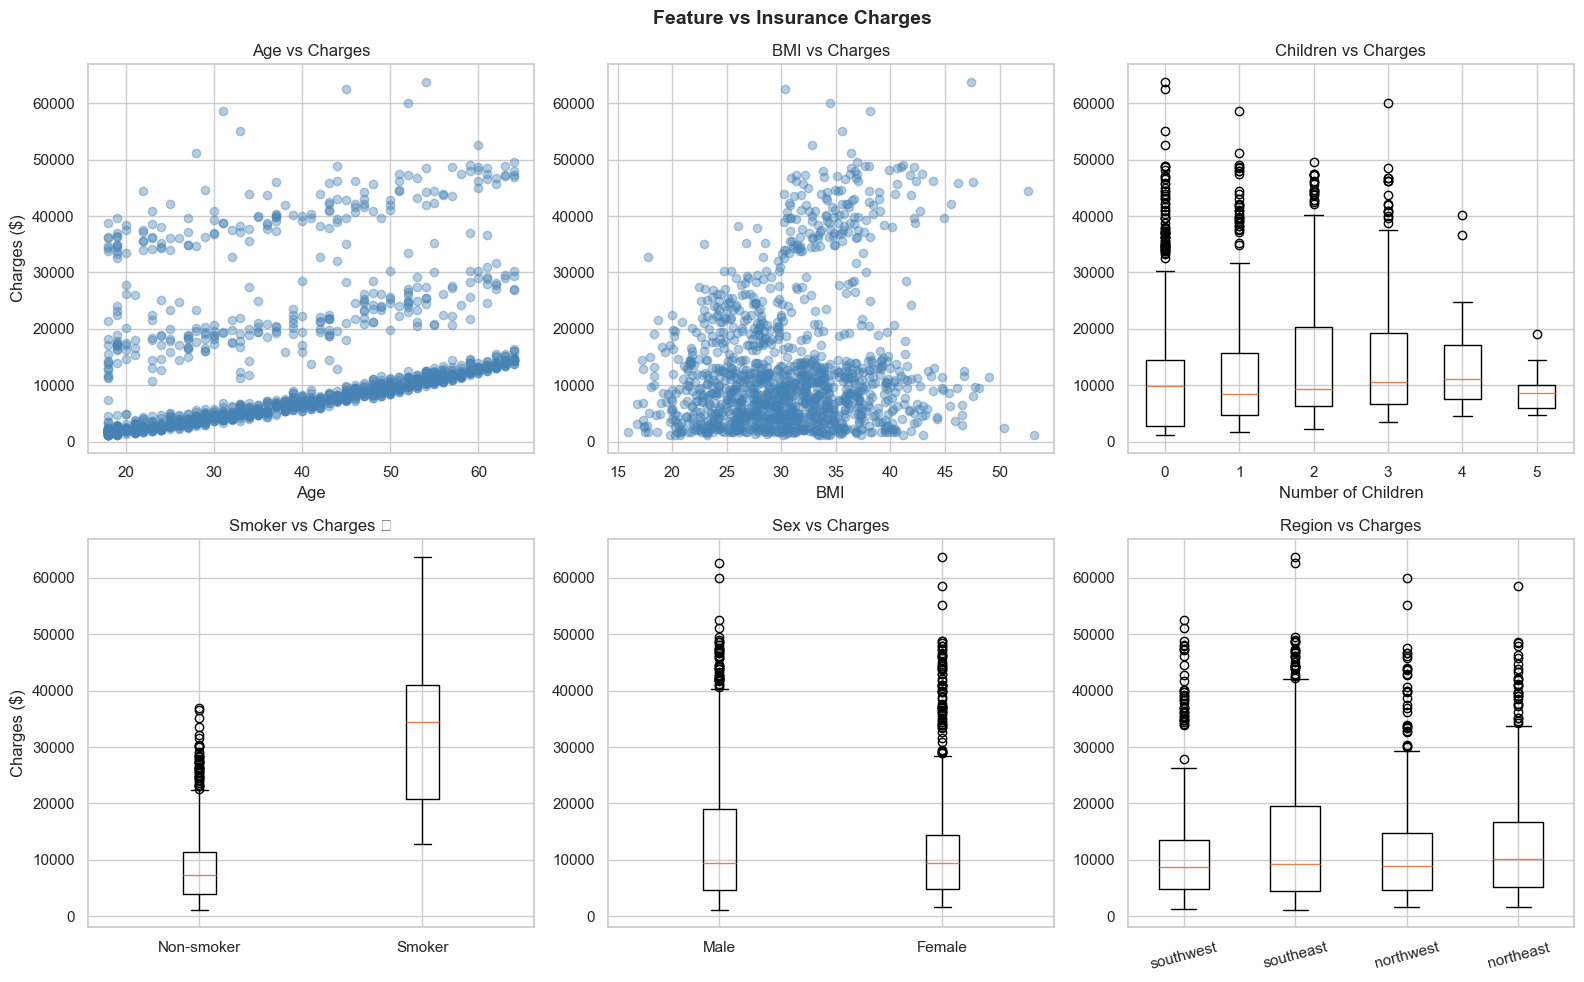

In [5]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age vs Charges
axes[0,0].scatter(df['age'], df['charges'], alpha=0.4, color='steelblue')
axes[0,0].set_title('Age vs Charges')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Charges ($)')

# BMI vs Charges
axes[0,1].scatter(df['bmi'], df['charges'], alpha=0.4, color='steelblue')
axes[0,1].set_title('BMI vs Charges')
axes[0,1].set_xlabel('BMI')

# Children vs Charges
axes[0,2].boxplot([df[df['children']==i]['charges'] for i in range(6)],
                  labels=range(6))
axes[0,2].set_title('Children vs Charges')
axes[0,2].set_xlabel('Number of Children')

# Smoker vs Charges (핵심!)
axes[1,0].boxplot([df[df['smoker']=='no']['charges'],
                   df[df['smoker']=='yes']['charges']],
                  labels=['Non-smoker', 'Smoker'])
axes[1,0].set_title('Smoker vs Charges ⭐')
axes[1,0].set_ylabel('Charges ($)')

# Sex vs Charges
axes[1,1].boxplot([df[df['sex']=='male']['charges'],
                   df[df['sex']=='female']['charges']],
                  labels=['Male', 'Female'])
axes[1,1].set_title('Sex vs Charges')

# Region vs Charges
axes[1,2].boxplot([df[df['region']==r]['charges'] for r in df['region'].unique()],
                  labels=df['region'].unique())
axes[1,2].set_title('Region vs Charges')
axes[1,2].tick_params(axis='x', rotation=15)

plt.suptitle('Feature vs Insurance Charges', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

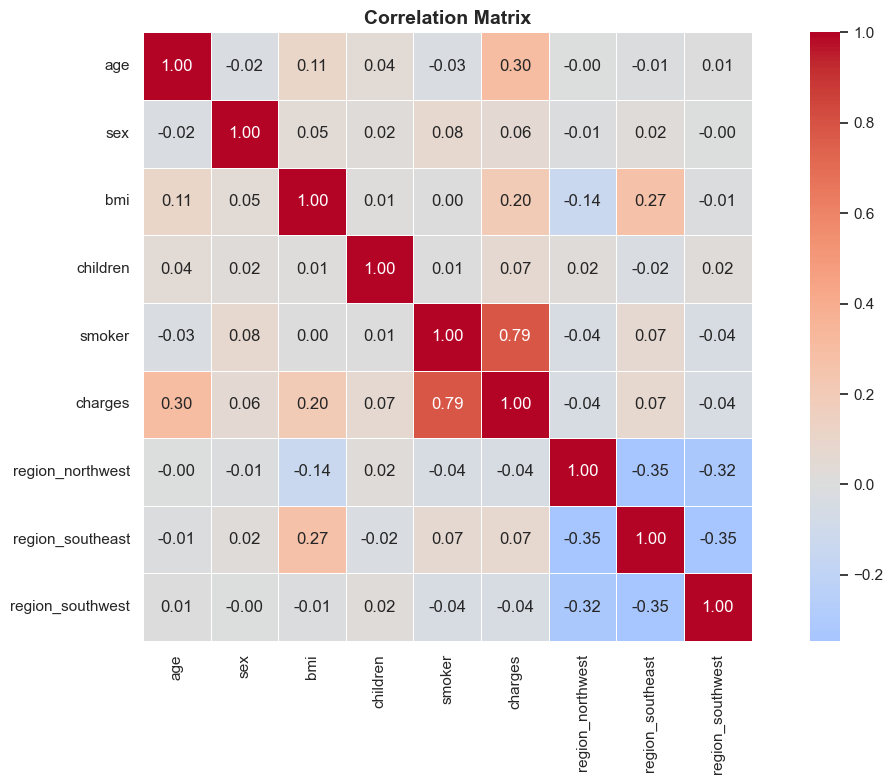

=== Correlation with Charges ===
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [9]:

# Encode categorical variables for correlation
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Correlation matrix
corr = df_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Charges correlation specifically
print("=== Correlation with Charges ===")
print(corr['charges'].sort_values(ascending=False))

In [11]:

print("=== Average Charges Comparison ===")
print(f"Smoker:    ${df[df['smoker']=='yes']['charges'].mean():,.0f}")
print(f"Non Smoker:  ${df[df['smoker']=='no']['charges'].mean():,.0f}")
print(f"Difference:      {df[df['smoker']=='yes']['charges'].mean() / df[df['smoker']=='no']['charges'].mean():.1f}✕Higher\n")

print(f"Male:      ${df[df['sex']=='male']['charges'].mean():,.0f}")
print(f"Female:      ${df[df['sex']=='female']['charges'].mean():,.0f}")
diff = abs(df[df['sex']=='male']['charges'].mean() - df[df['sex']=='female']['charges'].mean())
print(f"Difference:      ${diff:,.0f}\n")

print("=== Average insurance charge regard to region ===")
print(df.groupby('region')['charges'].mean().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

=== Average Charges Comparison ===
Smoker:    $32,050
Non Smoker:  $8,434
Difference:      3.8✕Higher

Male:      $13,957
Female:      $12,570
Difference:      $1,387

=== Average insurance charge regard to region ===
region
southeast    $14,735
northeast    $13,406
northwest    $12,418
southwest    $12,347
Name: charges, dtype: object


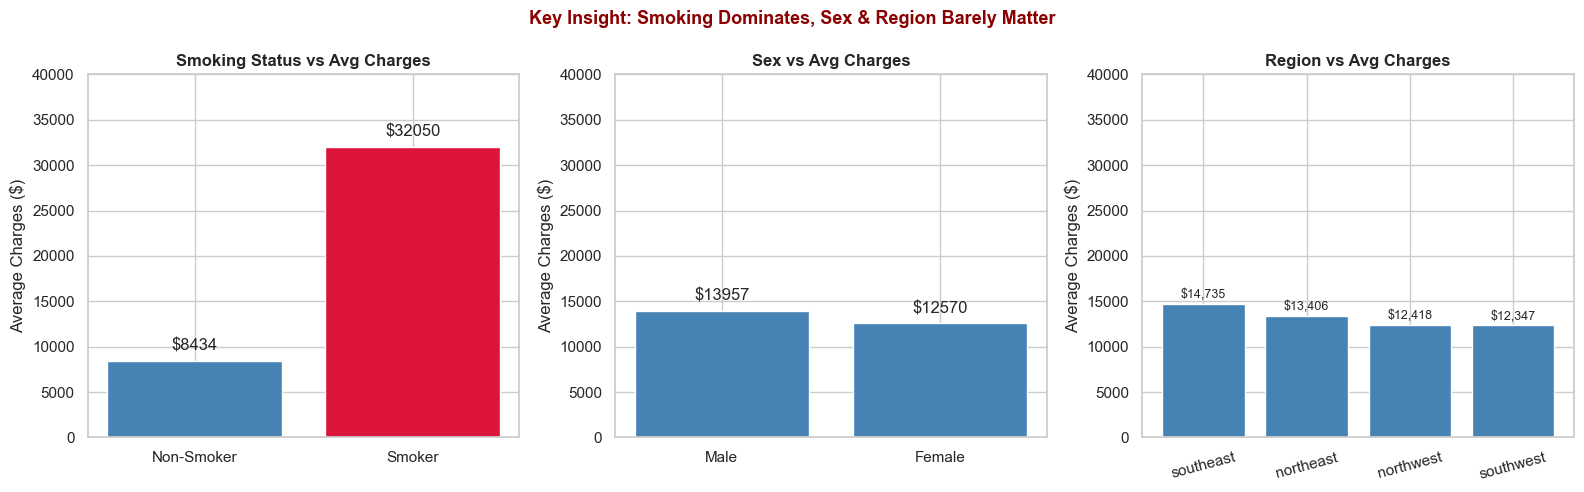

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Smoker impact
smoker_avg = df.groupby('smoker')['charges'].mean()
bars1 = axes[0].bar(['Non-Smoker', 'Smoker'], 
                     [smoker_avg['no'], smoker_avg['yes']],
                     color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Smoking Status vs Avg Charges', fontweight='bold')
axes[0].set_ylabel('Average Charges ($)')
axes[0].bar_label(bars1, fmt='$%.0f', padding=5)
axes[0].set_ylim(0, 40000)

# Sex impact
sex_avg = df.groupby('sex')['charges'].mean()
bars2 = axes[1].bar(['Male', 'Female'],
                     [sex_avg['male'], sex_avg['female']],
                     color=['steelblue', 'steelblue'], edgecolor='white')
axes[1].set_title('Sex vs Avg Charges', fontweight='bold')
axes[1].set_ylabel('Average Charges ($)')
axes[1].bar_label(bars2, fmt='$%.0f', padding=5)
axes[1].set_ylim(0, 40000)

# Region impact
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False)
bars3 = axes[2].bar(list(region_avg.index), list(region_avg.values),
                     color='steelblue', edgecolor='white')
axes[2].set_title('Region vs Avg Charges', fontweight='bold')
axes[2].set_ylabel('Average Charges ($)')
for bar, val in zip(bars3, region_avg.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylim(0, 40000)
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Key Insight: Smoking Dominates, Sex & Region Barely Matter', 
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()